In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Redes neuronales para el reconocimiento de voz a partir de espectrogramas


Se aplicarán redes neuronales convolucionales (CNN) en la aplicacion de clasificación multiclase basado en el procesamiento de señales en imagenes utilizando aprendizaje supervisado. Además de explorar herramientas para el desarrollo de modelos desde cero de redes neuronales, procesos de monitoreo de entrenamiento y bitacoras.

* Se revisará cuantos elementos tiene el archivo de datos de audio
* Se realizara la conversion de estos datos de audio a imagenes, especificamente un espectograma


#### Revision de elementos


In [2]:
import os
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

ruta = "/content/drive/MyDrive/Trabajos U/Dataset_esc50/audio"
extension = '.wav'

#listar los archivos y filtrar por extension

try:
    contador = len([archivo for archivo in os.listdir(ruta) if archivo.endswith(extension)])
    print(f'El total de archivos {extension} es: {contador}')
except FileNotFoundError:
    print("la ruta no existe")

El total de archivos .wav es: 2000


---

#### Conversion de elementos .wav a espectogramas 224x224

Se utiliza librosa para obtener con la FFT la frecuencia de muestreo para cada uno de los audios y poder construir los espectogramas con estas, ademas se hace en formato RGB con 3 canales para aumentar la informacion de cada imagen

In [3]:
#import librosa
#import numpy as np
#import matplotlib.cm as cm
#from PIL import Image
#from pathlib import Path

#ef wav_a_espectrograma_color_224(ruta_audio, ruta_salida_png, n_mels=224, cmap_name='magma'):
 #   try:
  #      # Cargar audio y calcular el Mel-espectrograma
   #     y, sr = librosa.load(ruta_audio, sr=None, mono=True)
    #    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=sr/2)
     #   S_db = librosa.power_to_db(S, ref=np.max)

        # Normalizar a 0-1 y aplicar color
      #  S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-8)
       # S_norm = np.flipud(S_norm) # Voltear para que bajas frecuencias queden abajo

       # cmap = cm.get_cmap(cmap_name)
       # colored = (cmap(S_norm)[..., :3] * 255).astype(np.uint8) # Aplicar colormap RGB

        # Redimensionar y guardar
       # im = Image.fromarray(colored, mode="RGB").resize((224, 224), Image.BILINEAR)
       # Path(ruta_salida_png).parent.mkdir(parents=True, exist_ok=True)
       # im.save(ruta_salida_png)

       # print(f"Espectrograma creado: {ruta_salida_png}")

   # except Exception as e:
    #    print(f"Error al procesar {ruta_audio}: {e}")



#carpeta_audios = Path('D:/TEC/2 semestre 2025/IA/Proyecto/dataset/ESC-50-master/audio')
#carpeta_salida = Path('D:/TEC/2 semestre 2025/IA/Proyecto/dataset/espectrogramas')
#carpeta_salida.mkdir(parents=True, exist_ok=True) # Crea la carpeta si no existe

# CONVERTIR TODOS LOS AUDIOS .WAV
#for wav_path in carpeta_audios.glob('*.wav'):
#    ruta_png = carpeta_salida / f"{wav_path.stem}.png"
#    wav_a_espectrograma_color_224(wav_path, ruta_png, cmap_name='magma')

---

#### Carga de la metadata


Se debe cargar la metadata del dataset ESC-50 es importante ya que nos da caracteristicas puntuales acerca de cada audio transformado en un espectograma, los cuales deberiamos mapear a cada una de las celdas contenidas dentro del csv


In [4]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Trabajos U/Dataset_esc50/meta/esc50.csv")
print(df.head())

            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A


Se puede visualizar que son 2000 filas cada una con diferentes columnas de las cuales se obtiene informacion relevante para el proceso de pre entrenamiento.

---

#### Mapeo de espectogramas con la metadata del ESC-50


Esto es útil porque nos permite saber a cual audio o clase corresponde cada uno de los espectogramas que tenemos ya creados a partir de los audios del dataset


In [5]:
spect_path = "/content/drive/MyDrive/Trabajos U/Dataset_esc50/espectrogramas"
df["spect_path"] = df["filename"].apply(lambda x: os.path.join(spect_path, x.replace(".wav", ".png")))
pd.set_option('display.max_colwidth', None)
print(df.head())



            filename  fold  target        category  esc10  src_file take  \
0   1-100032-A-0.wav     1       0             dog   True    100032    A   
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A   
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A   
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B   
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A   

                                                                         spect_path  
0   /content/drive/MyDrive/Trabajos U/Dataset_esc50/espectrogramas/1-100032-A-0.png  
1  /content/drive/MyDrive/Trabajos U/Dataset_esc50/espectrogramas/1-100038-A-14.png  
2  /content/drive/MyDrive/Trabajos U/Dataset_esc50/espectrogramas/1-100210-A-36.png  
3  /content/drive/MyDrive/Trabajos U/Dataset_esc50/espectrogramas/1-100210-B-36.png  
4  /content/drive/MyDrive/Trabajos U/Dataset_esc50/espectrogramas/1-101296-A-19.png  


Las rutas como se puede observar se mapearon correctamente a cada una de las celdas correspondientes al archivo de esc50.csv esto nos permitira tener una relacion en cuanto a los espectogramas generados y los datos de la metadata. Ahora se procedera a realizar un analisis exploratorio de los datos.

---

In [6]:
#Cuantas muestras hay por categoria
df.groupby(["target", "category"]).size().reset_index(name="count")


,target,category,count
0,0,dog,40
1,1,rooster,40
2,2,pig,40
3,3,cow,40
4,4,frog,40
5,5,cat,40
6,6,hen,40
7,7,insects,40
8,8,sheep,40
9,9,crow,40


Como se puede observar existen 40 muestras tomadas por cada categoria y la cantidad de estas ultimas es de 50. Tambien podriamos visualizarlo en un grafico de barras de la siguiente manera.

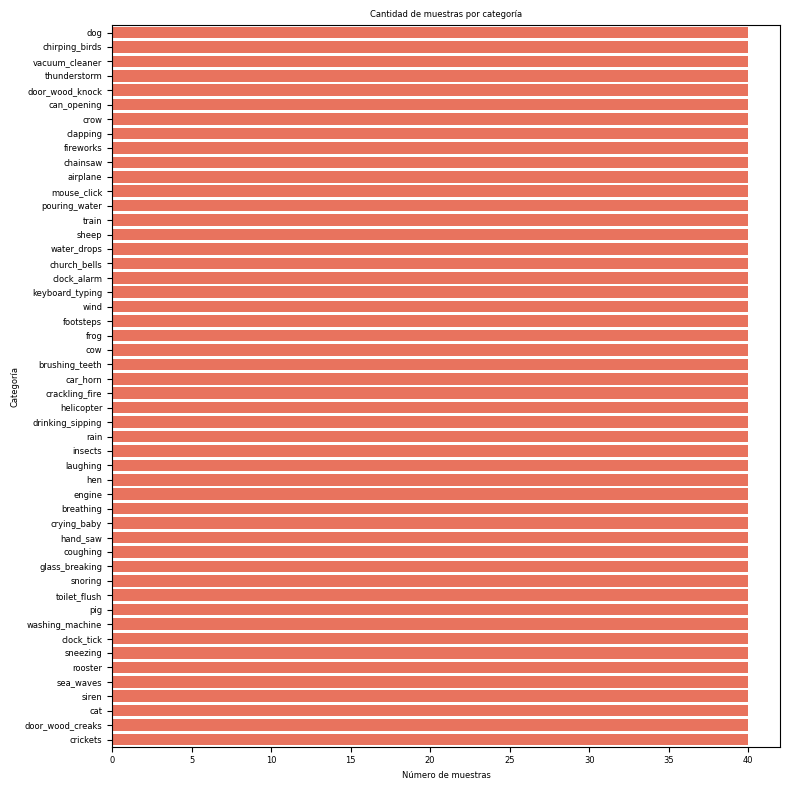

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,8))

sns.countplot(
    data=df,
    y="category",
    order=df["category"].value_counts().index,
    color="tomato"
)

plt.title("Cantidad de muestras por categoría", fontsize=6)
plt.xlabel("Número de muestras", fontsize=6)
plt.ylabel("Categoría", fontsize=6)
plt.yticks(fontsize=6)
plt.xticks(fontsize=6)
plt.tight_layout()
plt.show()




Con este diagrama de barras se puede verificar mas fielmente de manera visual la cantidad de categorias y muestras que se encuentran en la metadata brindada para el dataset esc-50

---

Ahora veremos los folds para confirmar que se tienen 400 muestras para cada fold y estos van del 1 al 5, esto valida que se pueden utilizar los folds para splitting (folds 1-3 train, 4 val, 5 test) sin introducir sesgos.

In [8]:
df.groupby("fold").size()

,0
fold,
1,400
2,400
3,400
4,400
5,400


In [9]:
df.groupby(["fold", "target"]).size().unstack(fill_value=0)


target,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
fold,,,,,,,,,,,,,,,,,,,,,
1,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
2,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
3,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
4,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
5,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8


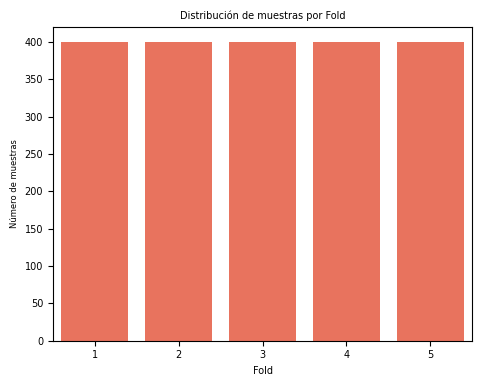

In [10]:
fold_counts = df.groupby("fold").size().reset_index(name="count")

plt.figure(figsize=(5,4))
sns.barplot(data=fold_counts, x="fold", y="count", color="tomato")

plt.title("Distribución de muestras por Fold", fontsize=7)
plt.xlabel("Fold", fontsize=7)
plt.ylabel("Número de muestras", fontsize=6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.yticks(fontsize=7)
plt.xticks(fontsize=7)
plt.show()


Como se puede observar los folds estan correctamente balanceados como se esperaba conteniendo cada fila un fold, cada columna las clases y dentro de estas 8 muestras de la clase especifica en ese fold, lo cual genera un resultado de 400 si se multiplica 8 * 50, esto para cada uno de los 5 folds

---

#### Espectogramas y visualizacion de patrones

Se realizara una visualizacion de 5 clases aleatorias y para cada una de estas 5 muestras de los espectogramas con el fin de observar si existe algun patron a simple vista, esto es util para determinar si las entradas son correctas y coherentes para la CNN.

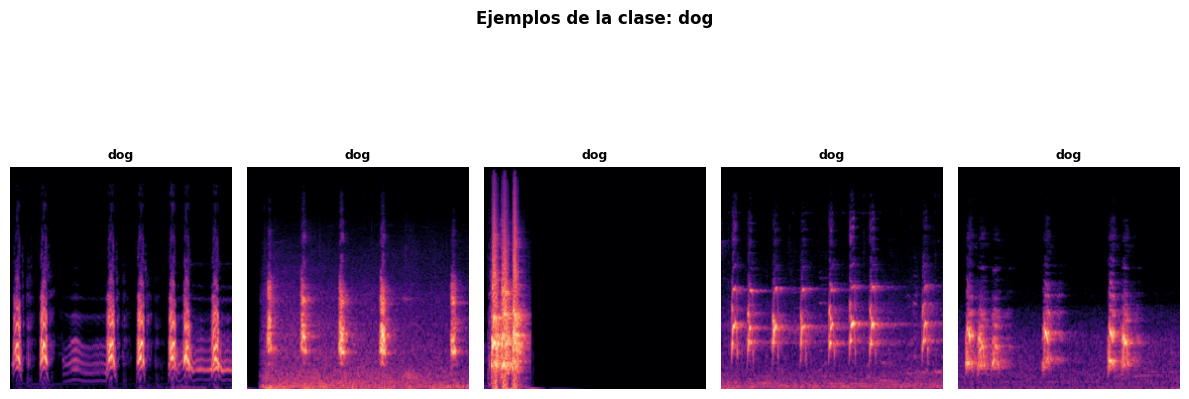

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Seleccionar aleatoriamente una categoría
clase = "dog"

# Filtrar 5 muestras de esa clase
ejemplos = df[df["category"] == clase].sample(5, random_state=None)

#  Visualización
plt.figure(figsize=(12, 6))
for i, (_, fila) in enumerate(ejemplos.iterrows()):
    img = mpimg.imread(fila["spect_path"])
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{clase}", fontsize=9, fontweight="bold")

plt.suptitle(f"Ejemplos de la clase: {clase}", fontsize=12, fontweight="bold", y=0.92)
plt.tight_layout()
plt.show()


Como se puede observar existen ciertos picos y colas o desvanecimiento hacia la derecha, esto corresponderia a que los perros por lo general al momento de ladrar tienen un ataque rapido, osea un inicio bastante abrupto de energia, es por esta razon tambien que en la parte baja del pico se observa un color mas brillante.

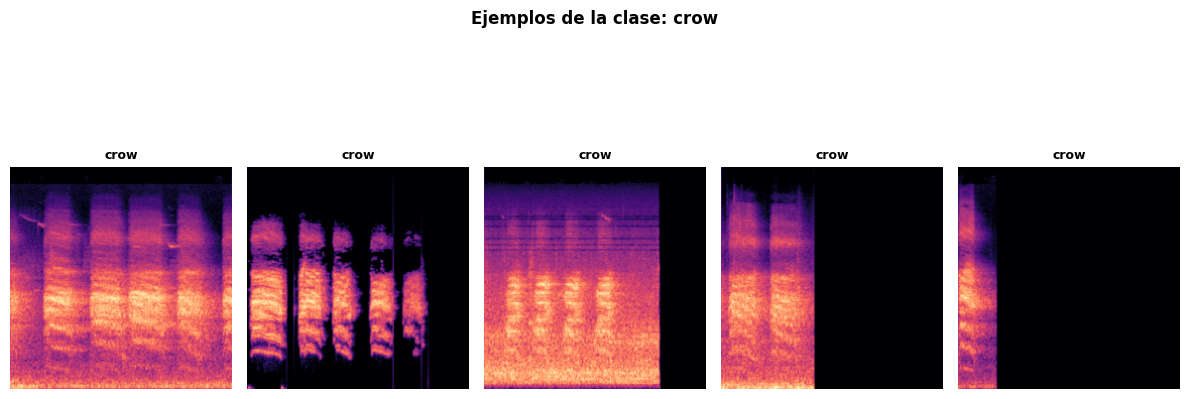

In [12]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Seleccionar aleatoriamente una categoría
clase = "crow"

# Filtrar 5 muestras de esa clase
ejemplos = df[df["category"] == clase].sample(5, random_state=None)

#  Visualización
plt.figure(figsize=(12, 6))
for i, (_, fila) in enumerate(ejemplos.iterrows()):
    img = mpimg.imread(fila["spect_path"])
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{clase}", fontsize=9, fontweight="bold")

plt.suptitle(f"Ejemplos de la clase: {clase}", fontsize=12, fontweight="bold", y=0.92)
plt.tight_layout()
plt.show()


Como se puede observar para este caso, el cuervo presenta un patrón rítmico de picos verticales que se repiten en el tiempo, típico de llamadas cortas, secuenciales y resonantes. Esto contrasta con clases más continuas (como “rain” o “vacuum_cleaner”), que muestran espectrogramas más densos y uniformes.

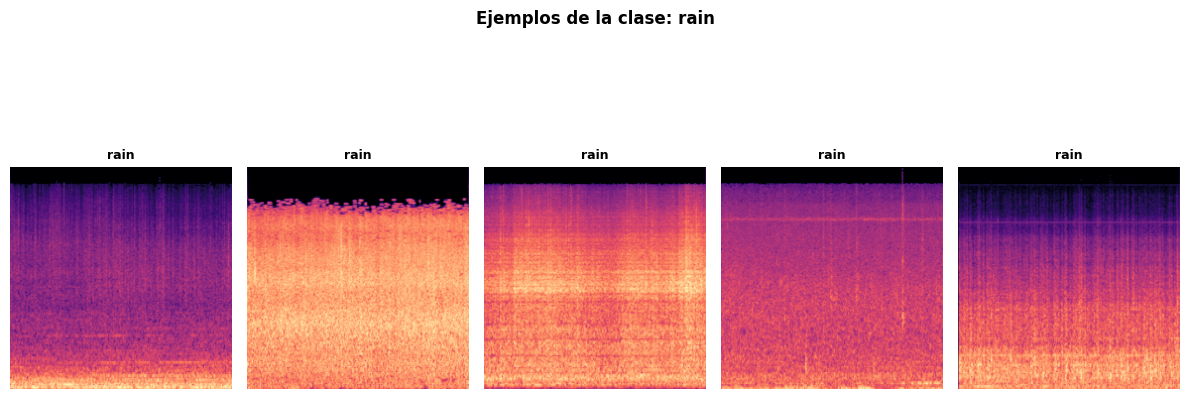

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Seleccionar aleatoriamente una categoría
clase = "rain"

# Filtrar 5 muestras de esa clase
ejemplos = df[df["category"] == clase].sample(5, random_state=None)

#  Visualización
plt.figure(figsize=(12, 6))
for i, (_, fila) in enumerate(ejemplos.iterrows()):
    img = mpimg.imread(fila["spect_path"])
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{clase}", fontsize=9, fontweight="bold")

plt.suptitle(f"Ejemplos de la clase: {clase}", fontsize=12, fontweight="bold", y=0.92)
plt.tight_layout()
plt.show()


Como se menciono anteriormente el patrón visual de la lluvia se caracteriza por una textura uniforme y difusa, con energía distribuida en casi todas las frecuencias y sin picos repetitivos. Esto contrasta con clases impulsivas como dog o crow, donde aparecen estructuras verticales bien definidas.

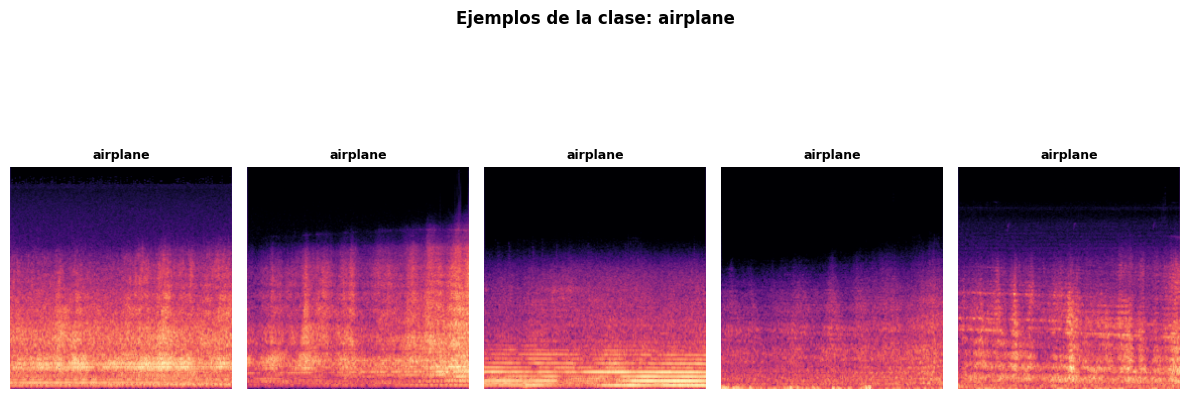

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Seleccionar aleatoriamente una categoría
clase = "airplane"

# Filtrar 5 muestras de esa clase
ejemplos = df[df["category"] == clase].sample(5, random_state=None)

#  Visualización
plt.figure(figsize=(12, 6))
for i, (_, fila) in enumerate(ejemplos.iterrows()):
    img = mpimg.imread(fila["spect_path"])
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{clase}", fontsize=9, fontweight="bold")

plt.suptitle(f"Ejemplos de la clase: {clase}", fontsize=12, fontweight="bold", y=0.92)
plt.tight_layout()
plt.show()


En este caso, el sonido del avión genera un patrón de energía continua en bajas frecuencias, con variaciones suaves en el tiempo. Es un ruido mecánico sostenido, caracterizado por sus bandas horizontales y un gradiente de intensidad típico del paso de motores en movimiento.

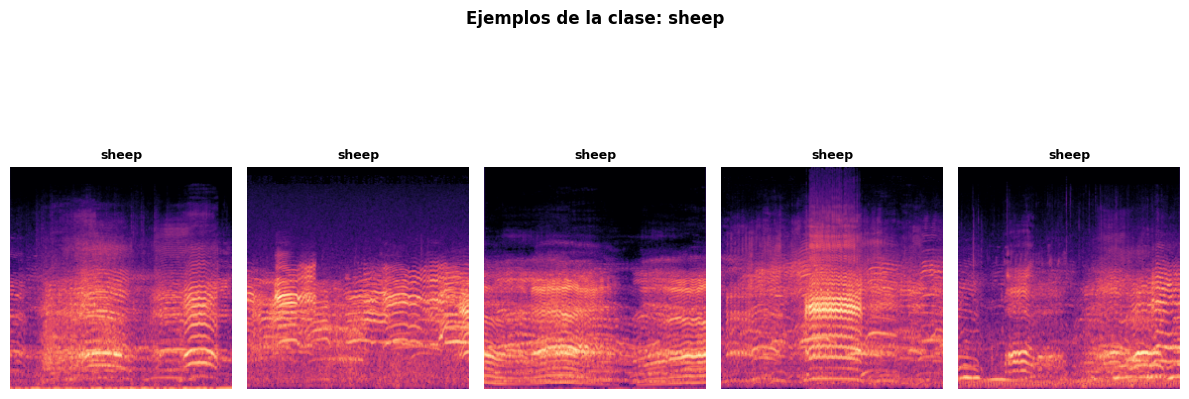

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Seleccionar aleatoriamente una categoría
clase = "sheep"

# Filtrar 5 muestras de esa clase
ejemplos = df[df["category"] == clase].sample(5, random_state=None)

#  Visualización
plt.figure(figsize=(12, 6))
for i, (_, fila) in enumerate(ejemplos.iterrows()):
    img = mpimg.imread(fila["spect_path"])
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{clase}", fontsize=9, fontweight="bold")

plt.suptitle(f"Ejemplos de la clase: {clase}", fontsize=12, fontweight="bold", y=0.92)
plt.tight_layout()
plt.show()


Para el sonido de la oveja podemos observar que se producen patrones de armónicos claros y repetitivos, con bandas horizontales bien definidas y separadas, que reflejan la naturaleza vocal del balido. Es un sonido periódico y tonal, muy distinto de ruidos continuos como rain o vacuum_cleaner.

Como podemos observar en estos 5 ejemplos mostrados anteriormente, existen relaciones muy fuertes entre la posicion de los pixeles y el color de estos mismos, de modo que a simple vista podemos imaginar como se comporta el sonido teniendo en cuenta estos factores, por lo tanto son factores que la CNN tomara en cuenta a la hora de pasar los filtros cada uno de estos se ajustara de modo que se vayan obteniendo diferentes caracteristicas de la imagen por cada convolucion que se este realizando.

---

#### Normalizacion

Debido a que las imagenes seran entradas para la CNN de arquitectura ResNet es necesario aplicar una normalizacion sobre la misma calculando la media y la desviacion estandar primeramente para obtener estas dos estadisticas descriptivas que nos ayudaran a normalizar.

In [16]:
#Media y desviacion obtenidos de forma local para la normalizacion
MEAN = [0.4241387,  0.1550668,  0.31883597]
STD = [0.35462896, 0.16410387,  0.19566532]


Como se puede observar se obtuvo la media por cada canal en un intervalo de [0,1] ademas la desviacion estandar para cada canal de la misma manera en ese mismo intervalo, esto nos permitira realizar una normalizacion correcta de los valores de pixeles en cada imagen para que puedan ser procesados de manera optima por la CNN con arquitectura ResNet.

In [17]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

# Estadísticas calculadas previamente

class ESC50Dataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Cargar imagen desde la ruta
        img_path = self.df.iloc[idx]["spect_path"]
        img = Image.open(img_path).convert("RGB")

        # Convertir a tensor en rango [0,1]
        img_array = np.array(img, dtype=np.float32) / 255.0
        img_tensor = torch.from_numpy(img_array).permute(2, 0, 1)

        # Normalización explícita canal por canal
        for c in range(3):
            img_tensor[c] = (img_tensor[c] - MEAN[c]) / STD[c]

        # Etiqueta numérica
        label = self.df.iloc[idx]["target"]

        return img_tensor, label

Se puede observar que se tomaron todas las imagenes para la normalizacion y se obtuvo un tamano de batch de [32,3,224,224] lo cual es correcto tomando en cuenta que se esta trabajando con imagenes de 3 canales de 224x224. Estos valores se cargan a Dataset y Dataloader para posteriormente poder utilizarlos en entrenamiento

---


#### Division del conjunto de entrenamiento, validation y test

Se utilizaran los folds dados los cuales son 5 y cada uno con 400 muestras de modo que tomaremos, 1200 muestras osea 3 folds para entrenamiento y validacion de 400 muestras y de igual manera para test con 400 muestras.

In [18]:
import pandas as pd
import torch

# Fijar seed para reproducibilidad
torch.manual_seed(42)

# Definir split
df_train = df[df["fold"].isin([1, 2, 3])]  # 1200 muestras
df_val = df[df["fold"] == 4]              # 400 muestras
df_test = df[df["fold"] == 5]             # 400 muestras

# Verificar balanceo
print("Clases entrenamiento:", df_train["target"].value_counts().describe())
print("Clases validacion:", df_val["target"].value_counts().describe())
print("Clases test", df_test["target"].value_counts().describe())

Clases entrenamiento: count    50.0
mean     24.0
std       0.0
min      24.0
25%      24.0
50%      24.0
75%      24.0
max      24.0
Name: count, dtype: float64
Clases validacion: count    50.0
mean      8.0
std       0.0
min       8.0
25%       8.0
50%       8.0
75%       8.0
max       8.0
Name: count, dtype: float64
Clases test count    50.0
mean      8.0
std       0.0
min       8.0
25%       8.0
50%       8.0
75%       8.0
max       8.0
Name: count, dtype: float64


In [19]:
# Dataset para cada split
train_dataset = ESC50Dataset(df_train)
val_dataset = ESC50Dataset(df_val)
test_dataset = ESC50Dataset(df_test)

# DataLoaders
batch_size = 32  #
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Verificar un batch
images, labels = next(iter(train_dataloader))
print("Train batch shape:", images.shape)  # [32, 3, 224, 224]
print("Train labels shape:", labels.shape)  # [32]

Train batch shape: torch.Size([32, 3, 224, 224])
Train labels shape: torch.Size([32])


Se genera un total de 32 imagenes normalizadas con 3 canales y de 224x224 para cada batch estos se utilizaran para el entrenamiento de los kernel que son parte de la CNN.

---

#### Resnet 18

Utilizaremos para el entrenamiento una arquitectura de redes neuronales profundas que utiliza bloques residuales con skip connections, permitiendo que la red aprenda funciones residuales en lugar de funciones completas. Esto facilita el entrenamiento de modelos muy profundos, evitando la degradación del rendimiento y mejorando la precisión en tareas de visión.

- implementar una clase para los bloques residuales de resnet los cuales se deben de aplicar para minimizar el error en capas profundas

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

#Mantener constante el kernel size de 3 y el padding de 1
# Configuración de convolución 3x3
conv_k_3 = lambda in_channels, out_channels, stride: nn.Conv2d(
    in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False
)

#Clase para los bloques residuales
# Bloque residual básico (para ResNet-18)
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = conv_k_3(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = conv_k_3(out_channels, out_channels, 1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    #funcion para realizar la suma de la salida de un bloque a la salida del bloque siguiente
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out





- Implementar la clase resnet ahora si una vez implementada la clase residual

In [21]:
import torch.optim as optim
# ResNet-18 adaptado para ESC-50
class ResNet18(nn.Module):
    def __init__(self, num_classes=50):
        super(ResNet18, self).__init__()
        self.in_channels = 64
        # Conv inicial y max pooling (estándar para 224x224)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        # Etapas: 2 bloques por etapa (64, 128, 256, 512 canales)
        self.layer1 = self.make_layer(64, 2, stride=1)
        self.layer2 = self.make_layer(128, 2, stride=2)
        self.layer3 = self.make_layer(256, 2, stride=2)
        self.layer4 = self.make_layer(512, 2, stride=2)
        # Average pooling y FC
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, num_blocks, stride):
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))  # [batch_size, 64, 112, 112]
        x = self.maxpool(x)                     # [batch_size, 64, 56, 56]
        x = self.layer1(x)                      # [batch_size, 64, 56, 56]
        x = self.layer2(x)                      # [batch_size, 128, 28, 28]
        x = self.layer3(x)                      # [batch_size, 256, 14, 14]
        x = self.layer4(x)                      # [batch_size, 512, 7, 7]
        x = self.avgpool(x)                     # [batch_size, 512, 1, 1]
        x = x.view(x.size(0), -1)               # [batch_size, 512]
        x = self.fc(x)                          # [batch_size, 50]
        return x

# Instanciar modelo
model_resnet18 = ResNet18(num_classes=50)

# Optimizador (ajustado para ESC-50)
optimizer = torch.optim.SGD(model_resnet18.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

In [22]:
# Verificar un batch
images, labels = next(iter(train_dataloader))
print("Train batch shape:", images.shape)  # [16, 3, 224, 224]
print("Train labels shape:", labels.shape)  # [16]

Train batch shape: torch.Size([32, 3, 224, 224])
Train labels shape: torch.Size([32])


Entrenamiento

In [23]:
import wandb
# Función de entrenamiento
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, run_name):
    best_val_acc = 0.0
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_loss /= train_total
        train_acc = train_correct / train_total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= val_total
        val_acc = val_correct / val_total

        wandb.log({"epoch": epoch+1, "train_loss": train_loss, "train_acc": train_acc,
                   "val_loss": val_loss, "val_acc": val_acc})

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'/content/drive/MyDrive/Trabajos U/Dataset_esc50/best_model_{run_name}.pth')

        print(f"Run {run_name}, Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return best_val_acc

# Configurar WandB Sweep
sweep_config = {
    "method": "grid",
    "metric": {"name": "val_acc", "goal": "maximize"},
    "parameters": {
        "learning_rate": {"values": [0.01, 0.001, 0.0001]},
        "optimizer": {"values": ["SGD", "Adam"]},
        "epochs": {"value": 10}
    }
}

# Crear sweep
sweep_id = wandb.sweep(sweep_config, project="esc50-resnet")

# Función para ejecutar un entrenamiento con WandB
def run_sweep():
    wandb.init(project="esc50-resnet")  # se inicia sin usar config todavía

    run_name = f"{wandb.config.optimizer}-lr{wandb.config.learning_rate}"
    wandb.run.name = run_name  # ahora renombramos el run

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ResNet18(num_classes=50).to(device)
    criterion = nn.CrossEntropyLoss()

    if wandb.config.optimizer == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=wandb.config.learning_rate, momentum=0.9, weight_decay=1e-4)
    else:
        optimizer = optim.Adam(model.parameters(), lr=wandb.config.learning_rate)

    best_val_acc = train_model(model, train_dataloader, val_dataloader, criterion, optimizer,
                               wandb.config.epochs, device, run_name)

    wandb.log({"best_val_acc": best_val_acc})
    wandb.finish()


# Iniciar sesión en WandB
wandb.login()

# Ejecutar sweep (5 combinaciones)
wandb.agent(sweep_id, run_sweep, count=5)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: juliojvv21lol (juliojvv21lol-costa-rica) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

Run Adam-lr0.001, Epoch 1/10, Train Loss: 3.6635, Train Acc: 0.0725, Val Loss: 4.5330, Val Acc: 0.1050
Run Adam-lr0.001, Epoch 2/10, Train Loss: 2.9667, Train Acc: 0.1933, Val Loss: 2.6611, Val Acc: 0.2725
Run Adam-lr0.001, Epoch 3/10, Train Loss: 2.5523, Train Acc: 0.2708, Val Loss: 2.8943, Val Acc: 0.2500
Run Adam-lr0.001, Epoch 4/10, Train Loss: 2.1805, Train Acc: 0.3608, Val Loss: 2.5882, Val Acc: 0.2900
Run Adam-lr0.001, Epoch 5/10, Train Loss: 1.8031, Train Acc: 0.4758, Val Loss: 2.1534, Val Acc: 0.3775
Run Adam-lr0.001, Epoch 6/10, Train Loss: 1.6193, Train Acc: 0.5117, Val Loss: 1.9748, Val Acc: 0.4300
Run Adam-lr0.001, Epoch 7/10, Train Loss: 1.3181, Train Acc: 0.5975, Val Loss: 1.6821, Val Acc: 0.4900
Run Adam-lr0.001, Epoch 8/10, Train Loss: 1.1331, Train Acc: 0.6517, Val Loss: 1.8034, Val Acc: 0.4875
Run Adam-lr0.001, Epoch 9/10, Train Loss: 1.0536, Train Acc: 0.6783, Val Loss: 1.6861, Val Acc: 0.5125
Run Adam-lr0.001, Epoch 10/10, Train Loss: 0.8810, Train Acc: 0.7392, Val

best_val_acc,▁
epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▂▃▄▅▆▇▇▇█
train_loss,█▆▅▄▃▃▂▂▁▁
val_acc,▁▄▃▄▅▆▇▇▇█
val_loss,█▃▄▃▂▂▁▁▁▁
best_val_acc,0.555
epoch,10
train_acc,0.73917
train_loss,0.88104
val_acc,0.555


wandb: Agent Starting Run: lez5rlog with config:
wandb: 	epochs: 10
wandb: 	learning_rate: 0.0001
wandb: 	optimizer: SGD


Run SGD-lr0.0001, Epoch 1/10, Train Loss: 3.9506, Train Acc: 0.0233, Val Loss: 3.8777, Val Acc: 0.0350
Run SGD-lr0.0001, Epoch 2/10, Train Loss: 3.7970, Train Acc: 0.0658, Val Loss: 3.7391, Val Acc: 0.1000
Run SGD-lr0.0001, Epoch 3/10, Train Loss: 3.6621, Train Acc: 0.1183, Val Loss: 3.6316, Val Acc: 0.1100
Run SGD-lr0.0001, Epoch 4/10, Train Loss: 3.5408, Train Acc: 0.1525, Val Loss: 3.5333, Val Acc: 0.1000
Run SGD-lr0.0001, Epoch 5/10, Train Loss: 3.4378, Train Acc: 0.1825, Val Loss: 3.4462, Val Acc: 0.1275
Run SGD-lr0.0001, Epoch 6/10, Train Loss: 3.3502, Train Acc: 0.2392, Val Loss: 3.3636, Val Acc: 0.1700
Run SGD-lr0.0001, Epoch 7/10, Train Loss: 3.2613, Train Acc: 0.2617, Val Loss: 3.2894, Val Acc: 0.1750
Run SGD-lr0.0001, Epoch 8/10, Train Loss: 3.1743, Train Acc: 0.3017, Val Loss: 3.2228, Val Acc: 0.1925
Run SGD-lr0.0001, Epoch 9/10, Train Loss: 3.0910, Train Acc: 0.3117, Val Loss: 3.1586, Val Acc: 0.2200
Run SGD-lr0.0001, Epoch 10/10, Train Loss: 3.0177, Train Acc: 0.3283, Val

best_val_acc,▁
epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▂▃▄▅▆▆▇██
train_loss,█▇▆▅▄▃▃▂▂▁
val_acc,▁▃▄▃▄▆▆▇██
val_loss,█▇▆▅▄▃▃▂▂▁
best_val_acc,0.22
epoch,10
train_acc,0.32833
train_loss,3.01775
val_acc,0.22


In [25]:
#Correr el entrenamiento con 5 diferents pruebas con distintos hiperparametros
def evaluate_model(model_path, test_loader, device):
    model = ResNet18(num_classes=50).to(device)  # Tu ResNet18
    model.load_state_dict(torch.load(model_path))
    model.eval()
    criterion = nn.CrossEntropyLoss()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    test_loss /= test_total
    test_acc = test_correct / test_total
    return test_loss, test_acc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model = "best_model_base-SGD-lr0.01.pth"  # Ajusta según el mejor run
test_loss, test_acc = evaluate_model(f'/content/drive/MyDrive/Trabajos U/Dataset_esc50/{best_model}', test_dataloader, device)
wandb.log({"test_loss": test_loss, "test_acc": test_acc})
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Trabajos U/Dataset_esc50/best_model_base-SGD-lr0.01.pth'